
Loading dataset...
Found 56 images belonging to 7 classes.
Found 14 images belonging to 7 classes.

Dataset information:
Number of classes: 7
Class names: ['dew', 'fogsmog', 'frost', 'lightning', 'rain', 'rainbow', 'snow']
Training samples: 56
Validation samples: 14

Training with 3 steps per epoch
Validating with 1 steps per epoch

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 31, 31, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 14, 14, 64) 

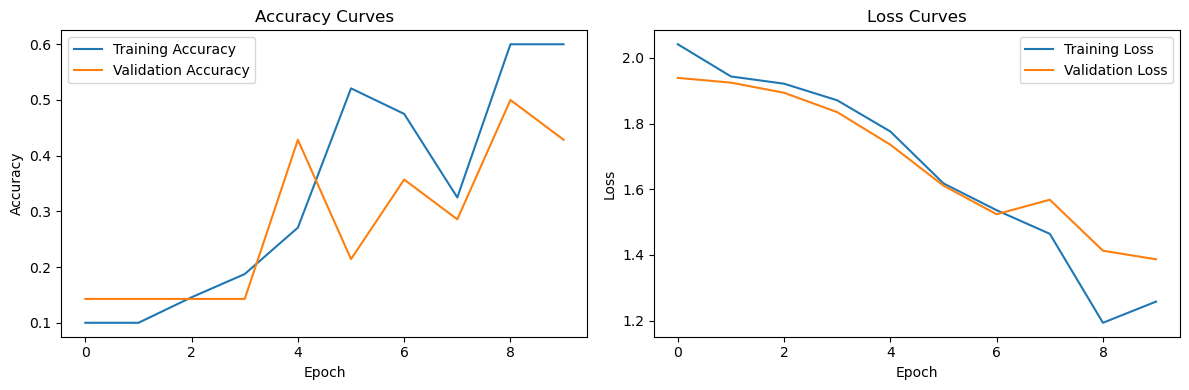

1/1 [==============================] - 0s 80ms/step - loss: 1.3866 - accuracy: 0.4286

Final Validation Accuracy: 42.86%
Final Validation Loss: 1.3866


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import os

def create_simple_cnn(input_shape, num_classes):
    """Create a simple CNN model"""
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
    return model

def train_and_evaluate(data_dir, image_size=(64, 64), batch_size=32, epochs=10):
    """Train and evaluate CNN model"""
    # Create data generators
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        validation_split=0.2)  # Using 20% for validation
    
    # Load training data
    train_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='training',
        shuffle=True)
    
    # Load validation data
    validation_generator = train_datagen.flow_from_directory(
        data_dir,
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        subset='validation',
        shuffle=True)
    
    # Print dataset information
    print("\nDataset information:")
    print(f"Number of classes: {len(train_generator.class_indices)}")
    print(f"Class names: {list(train_generator.class_indices.keys())}")
    print(f"Training samples: {train_generator.samples}")
    print(f"Validation samples: {validation_generator.samples}")
    
    # Calculate steps
    train_steps = max(1, train_generator.samples // batch_size)
    val_steps = max(1, validation_generator.samples // batch_size)
    
    print(f"\nTraining with {train_steps} steps per epoch")
    print(f"Validating with {val_steps} steps per epoch\n")
    
    # Get number of classes
    num_classes = len(train_generator.class_indices)
    
    # Create model
    model = create_simple_cnn((image_size[0], image_size[1], 3), num_classes)
    model.summary()
    
    # Train model
    history = model.fit(
        train_generator,
        steps_per_epoch=train_steps,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=val_steps)
    
    # Plot training history
    plot_history(history)
    
    # Evaluate model
    loss, accuracy = model.evaluate(validation_generator)
    print(f"\nFinal Validation Accuracy: {accuracy*100:.2f}%")
    print(f"Final Validation Loss: {loss:.4f}")
    
    return model

def plot_history(history):
    """Plot training and validation accuracy/loss curves"""
    plt.figure(figsize=(12, 4))
    
    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # Ask user for input folder path
    data_dir = r"C:\Users\admin\Pictures\archive (7)\dataset"
    
    # Verify path exists
    if not os.path.exists(data_dir):
        print("Error: The specified path does not exist.")
    else:
        print("\nLoading dataset...")
        try:
            # Use smaller batch size if dataset is small
            train_and_evaluate(data_dir, image_size=(64, 64), batch_size=16, epochs=10)
        except Exception as e:
            print(f"\nError occurred: {str(e)}")
            print("\nPossible solutions:")
            print("1. Make sure your dataset directory contains subdirectories for each class")
            print("2. Each class directory should contain at least a few images")
            print("3. Try reducing the batch size further (e.g., batch_size=8)")
            print("4. Check that images are in supported formats (jpg, png, etc.)")